In [1]:
#imports
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import sys
import os
from astropy.cosmology import Planck18 as cosmo
import ast




In [2]:
# --- User toggle ---
Cristina = False
Shar = not Cristina 

# --- System Configurations ---

if Cristina:
    print("[CONFIG] Using Cristina's local MacBook setup")
    sys.path.insert(0, "/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub")
    os.environ["RUBIN_SIM_DATA_DIR"] = "/Users/andradenebula/rubin_sim_data"
    db_dir = "/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub"
    base_dir = '/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output'

elif Shar:
    print("[CONFIG] Using Shar's Dirac server setup")
    sys.path.insert(0, "/lustre/lrspec/metrics")
    sys.path.insert(0, "/home/3155/metrics/Multi_Transient_Metrics_Hub")
    os.environ["RUBIN_SIM_DATA_DIR"] = "/lustre/lrspec/metrics/rubin_sim_data"
    db_dir = "/lustre/lrspec/metrics"
    base_dir = '/lustre/lrspec/metrics/results'

# Shared config
sys.path.append(os.path.abspath(".."))  # For shared_utils


[CONFIG] Using Shar's Dirac server setup


In [18]:
#this happens twice because idk why but it only works like that
#...you still have to run it twice if it gives warnings
# C: Make sure you save your metric file before running. 

metric_filename = "ShockCooling"
s_u = "shared_utils"

# --- Reload metric module ---
if metric_filename in sys.modules:
    del sys.modules[metric_filename]
metric = __import__(metric_filename)
importlib.reload(metric)

# --- Reload shared_utils module ---
if s_u in sys.modules:
    del sys.modules[s_u]
shared_utils = __import__(s_u)
importlib.reload(shared_utils)

print(f"[INFO] Loaded metric module: {metric_filename}")
print(f"[INFO] Loaded shared_utils module")



[INFO] Loaded metric module: ShockCooling
[INFO] Loaded shared_utils module


In [23]:
use_kcorrect = False
# k_correct_type='blackbody'
# k_correct_arg=25000 
k_correct_type = None
k_correct_arg = None

#metric configurations
#metric configurations
testname=None 

#use this to add text to the filename
#if you're testing template or population variables other than the below variables

testname_metric_only=None 
#use this to add text to the filename for the observation record df only (does not change pop/template filenames)
#so for anything you're changing that's only about the detection criteria

use_log_time = False

#control whether we generate new files
generate_new_templates = True
generate_new_pop = False
make_debug_plots = False #toggle whether or not the pop generation makes plots

#population variables
rate_density = 1e-7
# previously had rate_per_year = 65000

# apply None for non-use case 
z_min, z_max = None, None #0.00226, 0.3
d_min, d_max = 10, 30 


#other
gal_lat_cut = None #latitude cut, for Galactic phenomena
use_extinction = True
t_start = 1 #start time in days
t_end = 3652

# Whether to remove Metric_temp_* folders after running
clean_temp = True  

#cadence variables
# cadences = ['four_roll_v4.3.1_10yrs', 'baseline_v4.3.1_10yrs','noroll_v3.6_10yrs', 'baseline_v3.6_10yrs']
cadences = ['four_roll_v5.0.0_10yrs', 'baseline_v5.0.0_10yrs','noroll_v3.6_10yrs','baseline_v3.6_10yrs']

ignore_triples = False #turn this to true to ignore triples
filters = ['u', 'g', 'r', 'i', 'z', 'y'] #doesn't work rn i think but
#if we wanted to look at less filters then we would adjust that here

# Standardized output paths for this science case
# paths = metric.get_output_paths(case_label="GRBafterglows")  # <- can change to 'KNe' etc.
paths = shared_utils.build_filenames(testname=testname,
                        testname_metric_only=testname_metric_only,
                        science_case="SCE", 
                        rate_density=rate_density, 
                        z_min=z_min, 
                        z_max=z_max,
                        d_min=d_min, 
                        d_max=d_max,
                        ignore_triples=ignore_triples,                   
                        use_extinction=use_extinction,
                        use_kcorrect=use_kcorrect,
                        base_dir=base_dir)


templates_file, pop_file, df_file, storage_dir, summary_filename = paths


SCE_den_4.2e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_True_kcor_False_None


In [19]:
#load and/or generate light curves
shared_lc_model = shared_utils.load_or_generate_templates(metric.LC,
    templates_file=templates_file,
    generate_new=generate_new_templates
)

[INFO] Generating 1000 light curve templates.
Saved synthetic light curve templates to /lustre/lrspec/metrics/results/SCE/SCE_den_4.2e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_True_kcor_False_None_templates.pkl
Loaded templates from /lustre/lrspec/metrics/results/SCE/SCE_den_4.2e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_True_kcor_False_None_templates.pkl


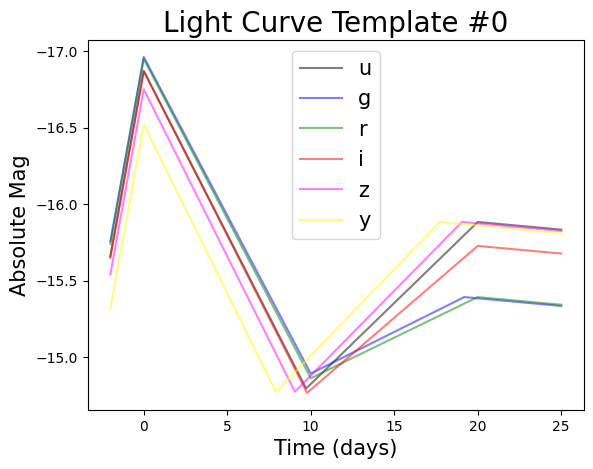

/home/3155/metrics/Multi_Transient_Metrics_Hub/shared_utils.py:149: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(prop={'size': 15})


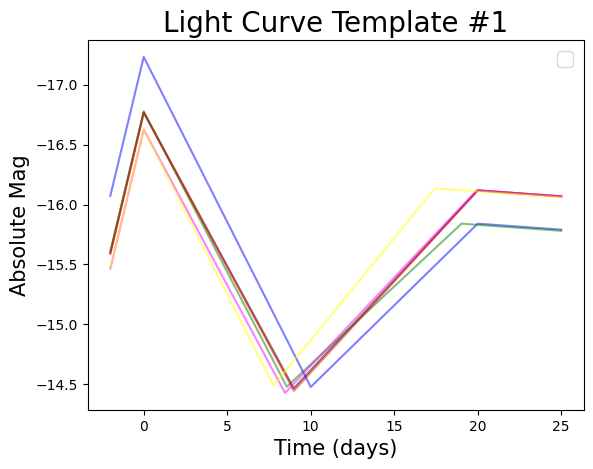

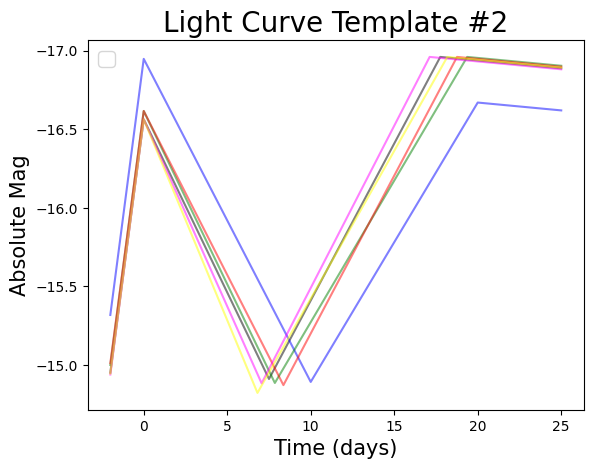

In [20]:
#plot light curves from pkl file if desired
# ylim=(-15, -21)
ylim=None
shared_utils.plot_some_lcs_from_pkl(templates_file, num=3, use_log_time = False,plot_overlap=False,ylim=ylim)

In [21]:
# Load or generate population slicer
slicer = shared_utils.load_or_generate_population(use_extinction=use_extinction,
    t_start=t_start,
    t_end=t_end,
    d_min=d_min,
    d_max=d_max,
    z_min=z_min,
    z_max=z_max,
    seed=42,
    num_lightcurves=1000,
    gal_lat_cut=gal_lat_cut,
    rate_density=rate_density,
    pop_file=pop_file,
    generate_new=generate_new_pop,
    make_debug_plots=make_debug_plots
)

[INFO] Generating population and saving to /lustre/lrspec/metrics/results/SCE/SCE_den_4.2e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_True_kcor_False_None_population.pkl
[INFO] z_min = 0.00226 → d_min = 10.008475172186685 Mpc
[INFO] z_max = 0.30000 → d_max = 1232.706667272352888 Mpc
Simulated 32836 events using rate_density = 4.2e-07
Len ra before masking:  32836
initial peak times:  [ 967.4806238  1674.61819953 1803.32444507 ...  250.34648716 1309.96681876
  182.84647549]
gal_lat_cut is none
Saved population to /lustre/lrspec/metrics/results/SCE/SCE_den_4.2e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_True_kcor_False_None_population.pkl
DEBUG: type(peak_times) = <class 'numpy.ndarray'>
DEBUG: shape(peak_times) = (32836,)


## All 10 years

In [26]:
importlib.reload(metric)

/lustre/lrspec/users/3155/anaconda3/envs/rubin_sim_223/lib/python3.11/site-packages/rubin_sim/maf/metrics/base_metric.py:32: UserWarning: Redefining metric ShockCooling.SCECharacterizeMetric! (there are >1 metrics with the same name)
  warnings.warn("Redefining metric %s! (there are >1 metrics with the same name)" % (metricname))


<module 'ShockCooling' from '/home/3155/metrics/Multi_Transient_Metrics_Hub/ShockCooling/ShockCooling.py'>


--- Running four_roll_v5.0.0_10yrs ---
EBV included

Inspecting one obs_record before saving to CSV:
mjd_obs         | type: <class 'list'> | length: 784
mag_obs         | type: <class 'list'> | length: 784
snr_obs         | type: <class 'list'> | length: 784
filter          | type: <class 'list'> | length: 784
first_det_mjd   | type: <class 'float'> | value: nan
last_det_mjd    | type: <class 'float'> | value: nan
fade_time_days  | type: <class 'float'> | value: nan
sid_duplicate   | type: <class 'numpy.int64'> | value: 1
file_indx       | type: <class 'numpy.int64'> | value: 740
ra              | type: <class 'numpy.float64'> | value: 0.6135923151542564
dec             | type: <class 'numpy.float64'> | value: -0.5848608108840141
distance_Mpc    | type: <class 'numpy.float64'> | value: 546.6243500087627
peak_mjd_observed | type: <class 'numpy.float64'> | value: 64291.287728805175
peak_mag_observed | type: <class 'numpy.float64'> | value: 137.71611446339543
ebv             | type: <cl

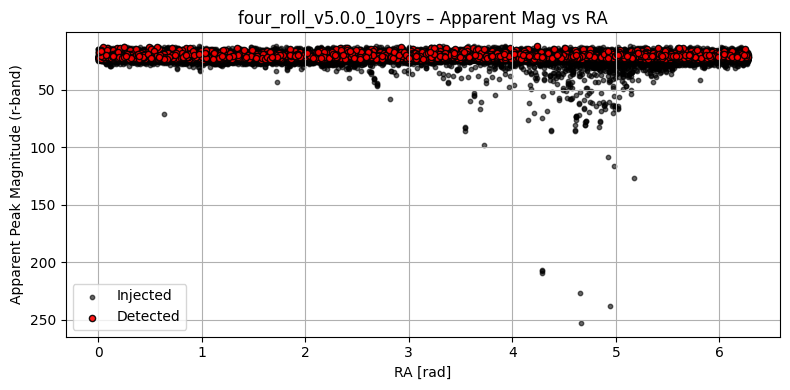

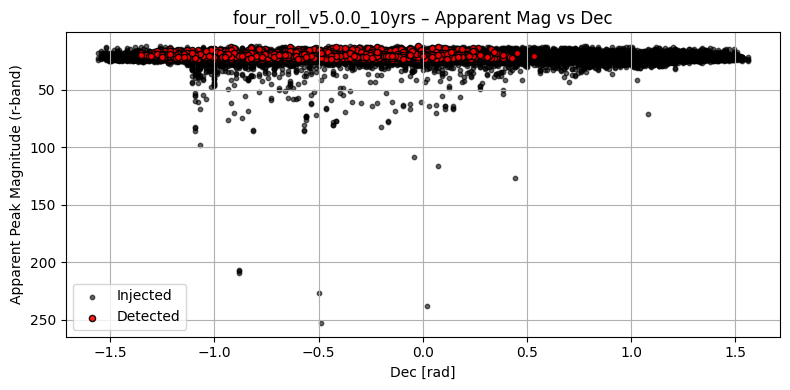

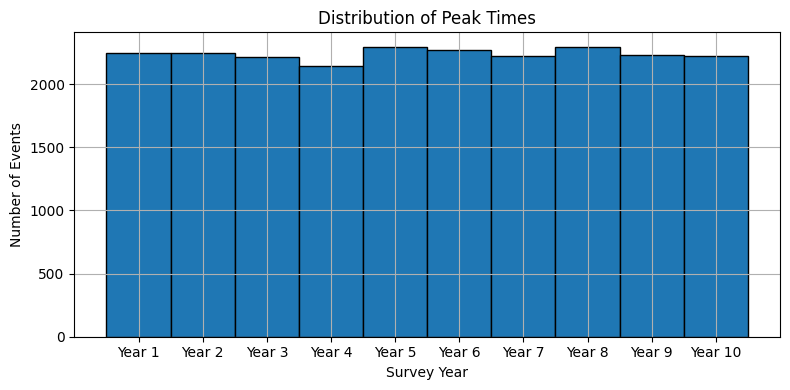

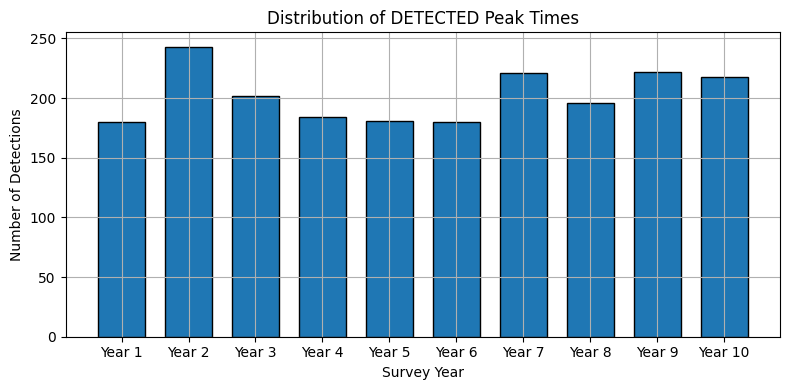

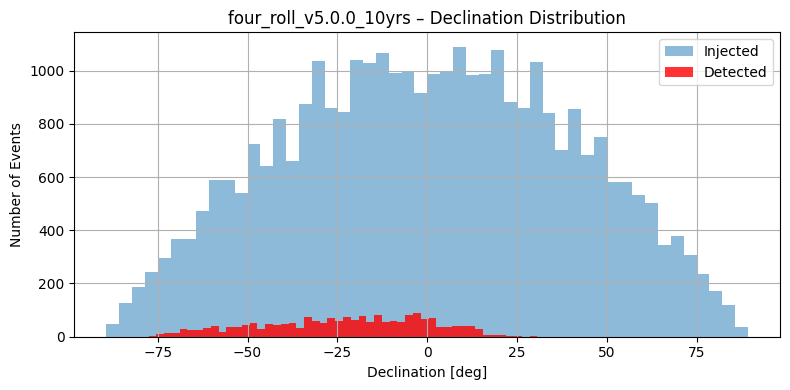

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_four_roll_v5.0.0_10yrs

--- Running baseline_v5.0.0_10yrs ---
EBV included

Inspecting one obs_record before saving to CSV:
mjd_obs         | type: <class 'list'> | length: 784
mag_obs         | type: <class 'list'> | length: 784
snr_obs         | type: <class 'list'> | length: 784
filter          | type: <class 'list'> | length: 784
first_det_mjd   | type: <class 'float'> | value: nan
last_det_mjd    | type: <class 'float'> | value: nan
fade_time_days  | type: <class 'float'> | value: nan
sid_duplicate   | type: <class 'numpy.int64'> | value: 1
file_indx       | type: <class 'numpy.int64'> | value: 740
ra              | type: <class 'numpy.float64'> | value: 0.6135923151542564
dec             | type: <class 'numpy.float64'> | value: -0.5848608108840141
distance_Mpc    | type: <class 'numpy.float64'> | value: 546.6243500087627
peak_mjd_observed | type: <class 'numpy.float64'> | value: 62461.22066292113
pe

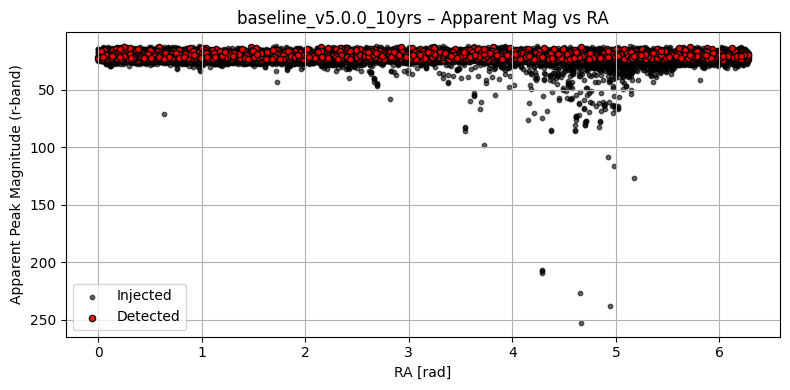

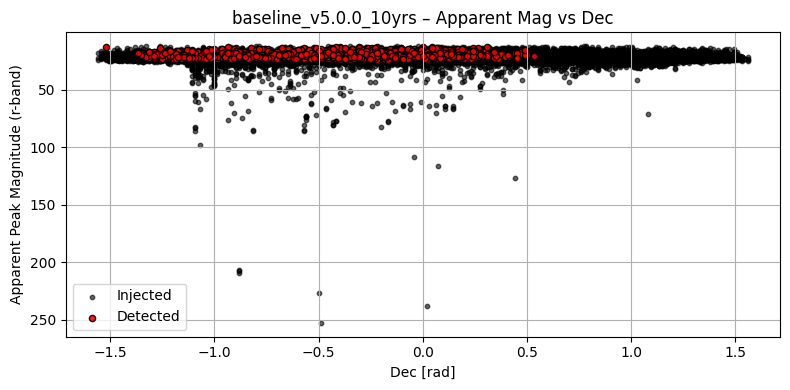

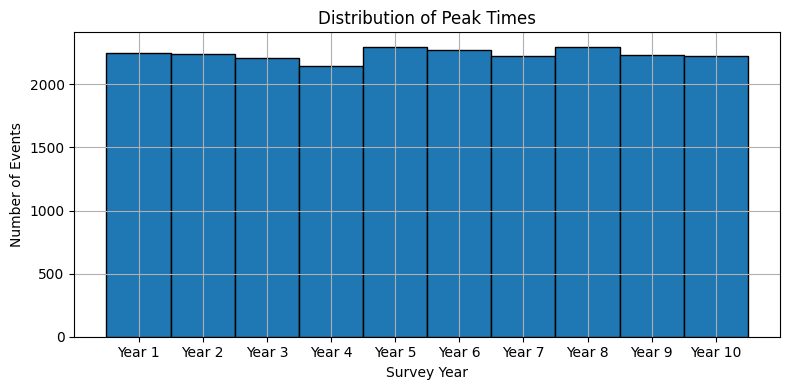

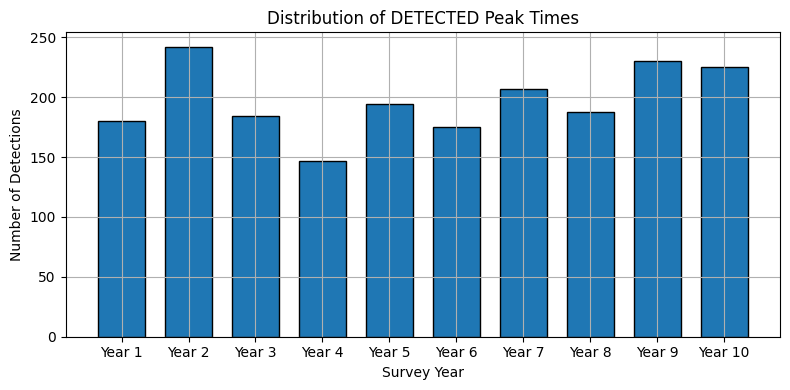

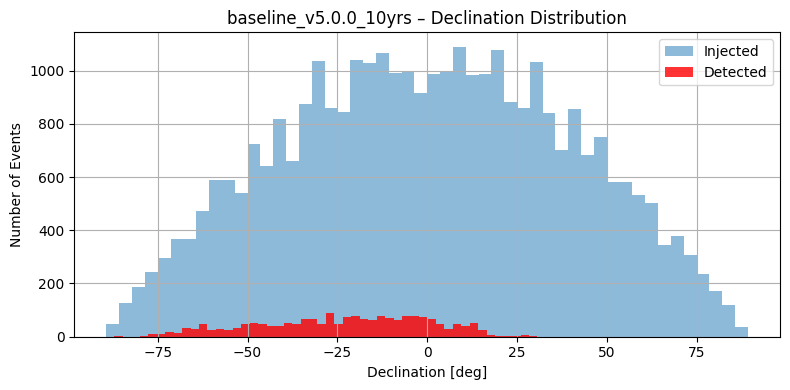

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_baseline_v5.0.0_10yrs

--- Running noroll_v3.6_10yrs ---
EBV included

Inspecting one obs_record before saving to CSV:
mjd_obs         | type: <class 'list'> | length: 747
mag_obs         | type: <class 'list'> | length: 747
snr_obs         | type: <class 'list'> | length: 747
filter          | type: <class 'list'> | length: 747
first_det_mjd   | type: <class 'float'> | value: nan
last_det_mjd    | type: <class 'float'> | value: nan
fade_time_days  | type: <class 'float'> | value: nan
sid_duplicate   | type: <class 'numpy.int64'> | value: 1
file_indx       | type: <class 'numpy.int64'> | value: 740
ra              | type: <class 'numpy.float64'> | value: 0.6135923151542564
dec             | type: <class 'numpy.float64'> | value: -0.5848608108840141
distance_Mpc    | type: <class 'numpy.float64'> | value: 546.6243500087627
peak_mjd_observed | type: <class 'numpy.float64'> | value: 61390.11870107106
peak_ma

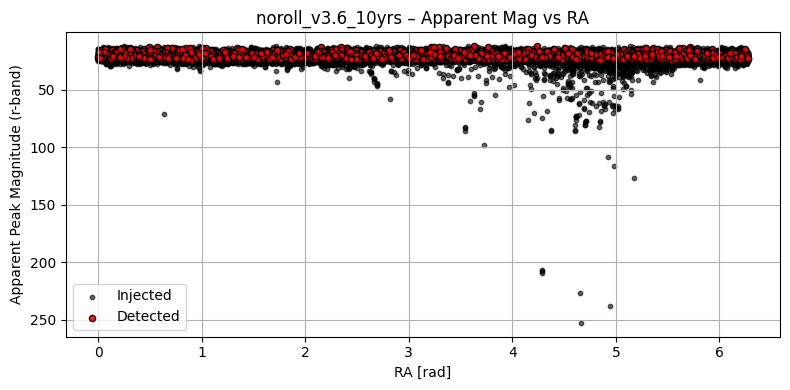

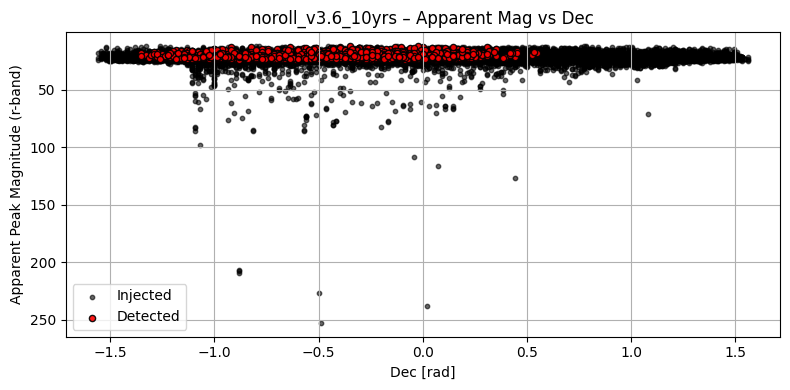

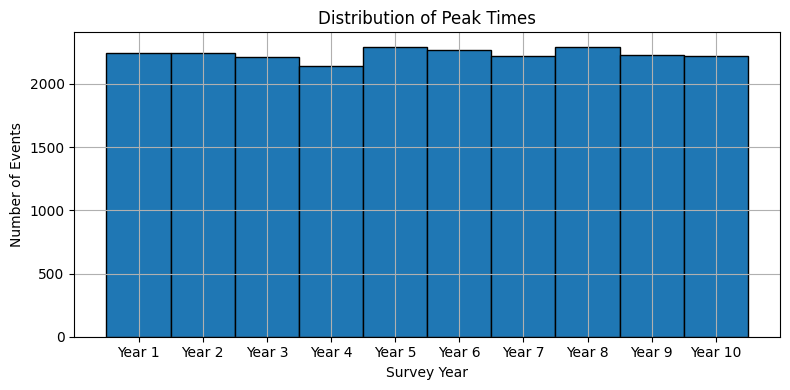

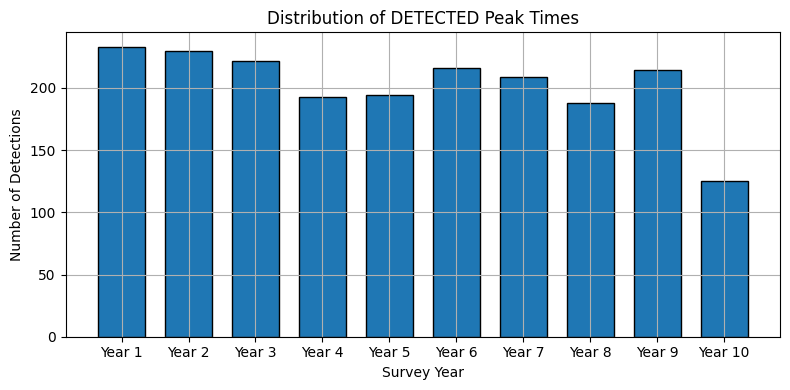

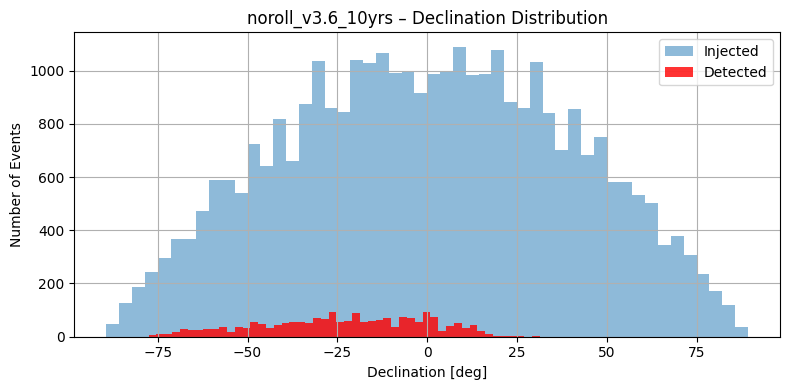

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_noroll_v3.6_10yrs

--- Running baseline_v3.6_10yrs ---
EBV included

Inspecting one obs_record before saving to CSV:
mjd_obs         | type: <class 'list'> | length: 719
mag_obs         | type: <class 'list'> | length: 719
snr_obs         | type: <class 'list'> | length: 719
filter          | type: <class 'list'> | length: 719
first_det_mjd   | type: <class 'float'> | value: nan
last_det_mjd    | type: <class 'float'> | value: nan
fade_time_days  | type: <class 'float'> | value: nan
sid_duplicate   | type: <class 'numpy.int64'> | value: 1
file_indx       | type: <class 'numpy.int64'> | value: 740
ra              | type: <class 'numpy.float64'> | value: 0.6135923151542564
dec             | type: <class 'numpy.float64'> | value: -0.5848608108840141
distance_Mpc    | type: <class 'numpy.float64'> | value: 546.6243500087627
peak_mjd_observed | type: <class 'numpy.float64'> | value: 63875.325833605835
peak_mag

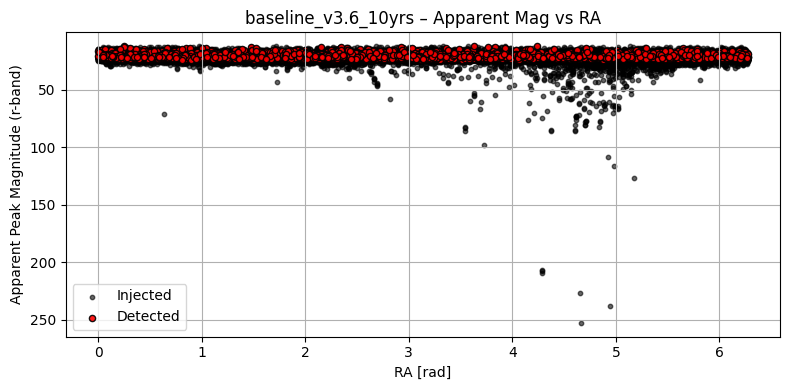

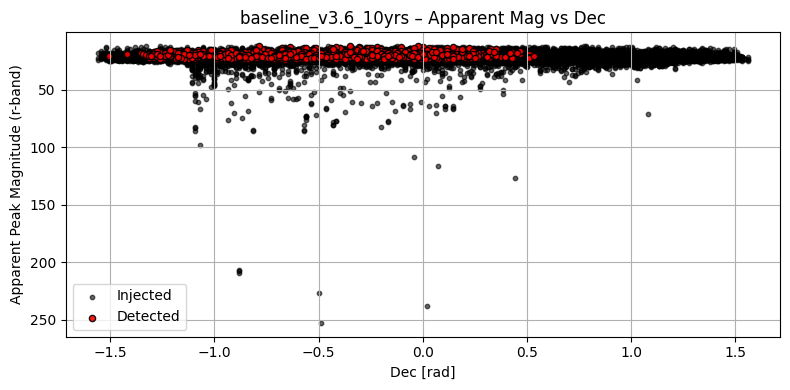

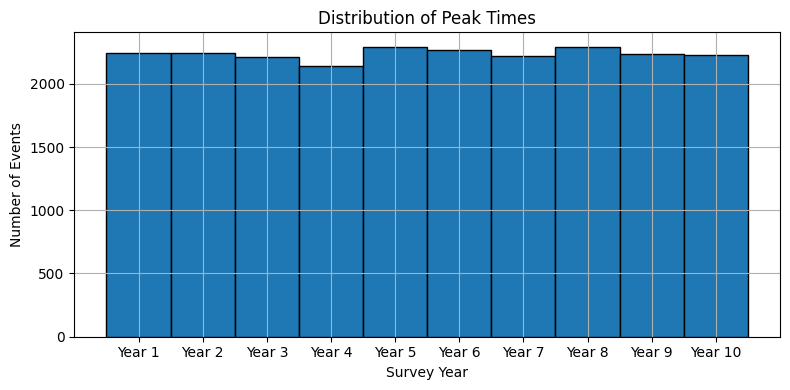

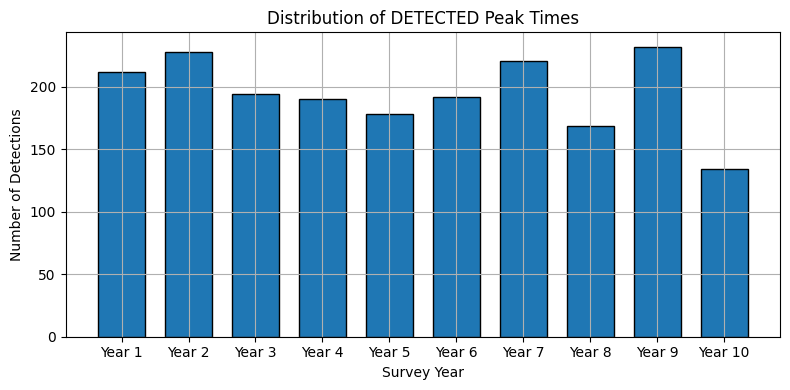

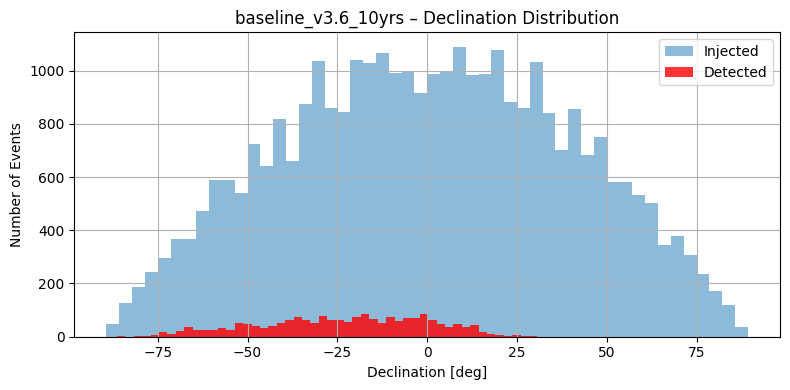

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/SCE/Metric_temp_baseline_v3.6_10yrs


In [24]:
df_obs = shared_utils.run_detect(metric, 
                                 slicer, 
                                 cadences, 
                                 shared_lc_model, 
                                 db_dir, storage_dir, 
                                 df_file, 
                                 ignore_triples=ignore_triples, 
                                 debug=True, plot=True, 
                                 clean_temp=clean_temp,
                                 use_kcorrect=use_kcorrect,
                                 k_correct_type=k_correct_type,
                                 k_correct_arg=k_correct_arg,
                                 use_extinction=use_extinction)

In [ ]:
df_obs

In [37]:
importlib.reload(metric)

<module 'ShockCooling' from '/home/3155/metrics/Multi_Transient_Metrics_Hub/ShockCooling/ShockCooling.py'>

In [38]:
#choose what to run in run_multi_metrics #'detect',  'GRBcharacterize', 'GRB_spec_trigger', 'GRBDetect'
# we can remove historical if we want
multi_metrics = metric.get_multi_metrics(shared_lc_model, include=['characterize'], use_extinction=use_extinction, use_kcorrect=use_kcorrect, k_correct_type=k_correct_type, k_correct_arg=k_correct_arg)


In [40]:
shared_lc_model.durations

AttributeError: 'LC' object has no attribute 'durations'

In [39]:
sum_df = shared_utils.run_multi_metrics(multi_metrics, slicer, cadences, shared_lc_model, db_dir=db_dir, storage_dir=storage_dir,summary_filename=summary_filename, ignore_triples=False, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)


--- Running four_roll_v5.0.0_10yrs ---
(1,)
EBV included
Failed at slice_point {'idxs': array([1667331, 1862616,  805647, 1640776,  183242, 1862244,   20576,
       1858158,  818055, 1286444,  464696,   20624, 1629311, 1629312,
       1629313, 1286392,  464644,  496002,  495950,  438829,  423129,
        442800,  208673,   12159,  476348,   34311, 1512575,  476400,
        251201, 1316677, 1320375,  442824,  274124, 1316625,  274072,
         30769,  188267,  455015,  185739, 1512627,  442871,   64837,
        423077,   30821,  495058,  822353, 1735070,  822398,  208725,
        495110,  454963,   64785,  235792,  442847, 1320427,  660809,
         43439,  873441,  253611, 1718870, 1889556, 1253729, 1230967,
        809522,  843863,  253559,  192506, 1492779, 1491870,  660757,
        427952,  843913, 1642187,  427937, 1492831,  880048, 1718818,
       1639702,   49897, 1318489, 1491922,  420768, 1864896,  420812,
        832254,  403237, 1063543,  232645,  215778, 1253673, 1264301,
 

AttributeError: 'SCECharacterizeMetric' object has no attribute '_lc_model'

In [129]:
sum_df

,Sum,run,n_events_full_sky
four_roll_v5.0.0_10yrs_Detect_Metric,7123.0,four_roll_v5.0.0_10yrs,32865
four_roll_v5.0.0_10yrs_LFBOTCharacterizeMetric,2196.0,four_roll_v5.0.0_10yrs,32865
baseline_v5.0.0_10yrs_Detect_Metric,7302.0,baseline_v5.0.0_10yrs,32865
baseline_v5.0.0_10yrs_LFBOTCharacterizeMetric,2225.0,baseline_v5.0.0_10yrs,32865
noroll_v3.6_10yrs_Detect_Metric,7794.0,noroll_v3.6_10yrs,32865
noroll_v3.6_10yrs_LFBOTCharacterizeMetric,2226.0,noroll_v3.6_10yrs,32865
baseline_v3.6_10yrs_Detect_Metric,6856.0,baseline_v3.6_10yrs,32865
baseline_v3.6_10yrs_LFBOTCharacterizeMetric,2074.0,baseline_v3.6_10yrs,32865


In [100]:
sum_df

,Sum,run,n_events_full_sky
four_roll_v5.0.0_10yrs_Detect_Metric,1634.0,four_roll_v5.0.0_10yrs,32865
four_roll_v5.0.0_10yrs_LFBOTCharacterizeMetric,575.0,four_roll_v5.0.0_10yrs,32865
baseline_v5.0.0_10yrs_Detect_Metric,1636.0,baseline_v5.0.0_10yrs,32865
baseline_v5.0.0_10yrs_LFBOTCharacterizeMetric,552.0,baseline_v5.0.0_10yrs,32865
noroll_v3.6_10yrs_Detect_Metric,1522.0,noroll_v3.6_10yrs,32865
noroll_v3.6_10yrs_LFBOTCharacterizeMetric,504.0,noroll_v3.6_10yrs,32865
baseline_v3.6_10yrs_Detect_Metric,1513.0,baseline_v3.6_10yrs,32865
baseline_v3.6_10yrs_LFBOTCharacterizeMetric,506.0,baseline_v3.6_10yrs,32865


In [247]:
sum_df

,Sum,run,n_events_full_sky
four_roll_v4.3.1_10yrs_Detect_Metric,367.0,four_roll_v4.3.1_10yrs,7881
four_roll_v4.3.1_10yrs_LFBOTCharacterizeMetric,366.0,four_roll_v4.3.1_10yrs,7881
baseline_v4.3.1_10yrs_Detect_Metric,308.0,baseline_v4.3.1_10yrs,7881
baseline_v4.3.1_10yrs_LFBOTCharacterizeMetric,307.0,baseline_v4.3.1_10yrs,7881
noroll_v3.6_10yrs_Detect_Metric,328.0,noroll_v3.6_10yrs,7881
noroll_v3.6_10yrs_LFBOTCharacterizeMetric,328.0,noroll_v3.6_10yrs,7881
baseline_v3.6_10yrs_Detect_Metric,318.0,baseline_v3.6_10yrs,7881
baseline_v3.6_10yrs_LFBOTCharacterizeMetric,318.0,baseline_v3.6_10yrs,7881


(array([ 1.,  2.,  2.,  6.,  7., 20., 32., 59., 41., 44., 35., 43., 50.,
        36., 41., 26., 49., 33., 15., 12.]),
 array([13.27587902, 14.46348086, 15.65108269, 16.83868453, 18.02628636,
        19.21388819, 20.40149003, 21.58909186, 22.7766937 , 23.96429553,
        25.15189737, 26.3394992 , 27.52710104, 28.71470287, 29.9023047 ,
        31.08990654, 32.27750837, 33.46511021, 34.65271204, 35.84031388,
        37.02791571]),
 <BarContainer object of 20 artists>)

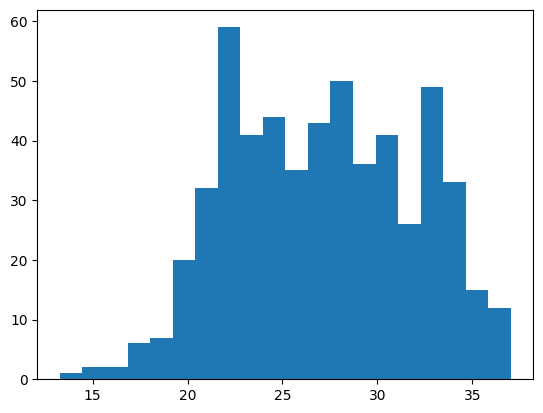

In [90]:
plt.hist(df_obs["peak_apparent_mag_g_noebv"],bins=20)

<Figure size 800x400 with 0 Axes>

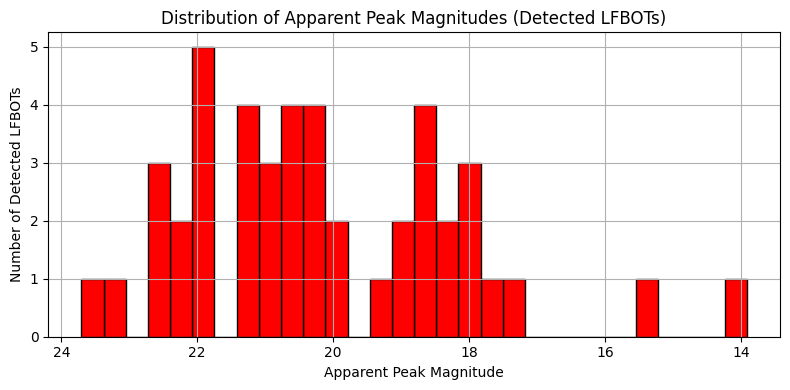

In [95]:
# Convert to numeric safely
valid_peak_mags = pd.to_numeric(detected_df['peak_mag_observed'], errors='coerce')

# Remove NaNs and cap at 99
valid_peak_mags = valid_peak_mags[np.isfinite(valid_peak_mags) & (valid_peak_mags < 99)]

# Plot
plt.figure(figsize=(8, 4))
plt.hist(valid_peak_mags, bins=30, edgecolor='black', color='red')
plt.xlabel("Apparent Peak Magnitude")
plt.ylabel("Number of Detected LFBOTs")
plt.title("Distribution of Apparent Peak Magnitudes (Detected LFBOTs)")
plt.gca().invert_xaxis()
plt.grid(True)
plt.tight_layout()
plt.show()


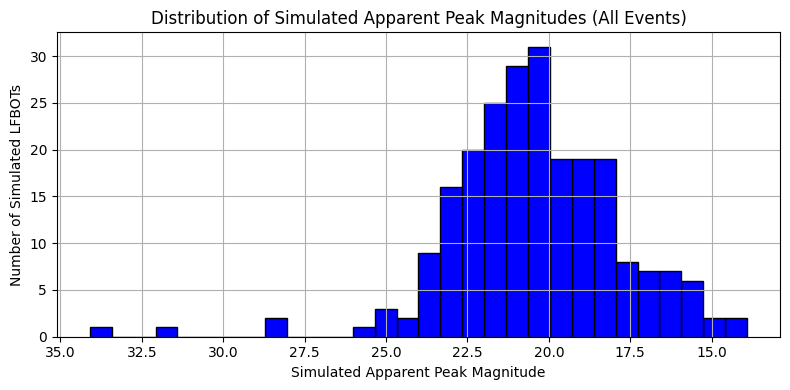

In [113]:
# All simulated events, regardless of detection
all_peak_mags = pd.to_numeric(df_obs['peak_mag_observed'], errors='coerce')
all_peak_mags = all_peak_mags[np.isfinite(all_peak_mags) & (all_peak_mags < 99)]

# Plot
plt.figure(figsize=(8, 4))
plt.hist(all_peak_mags, bins=30, edgecolor='black', color='blue')
plt.xlabel("Simulated Apparent Peak Magnitude")
plt.ylabel("Number of Simulated LFBOTs")
plt.title("Distribution of Simulated Apparent Peak Magnitudes (All Events)")
plt.gca().invert_xaxis()
plt.grid(True)
plt.tight_layout()
plt.show()


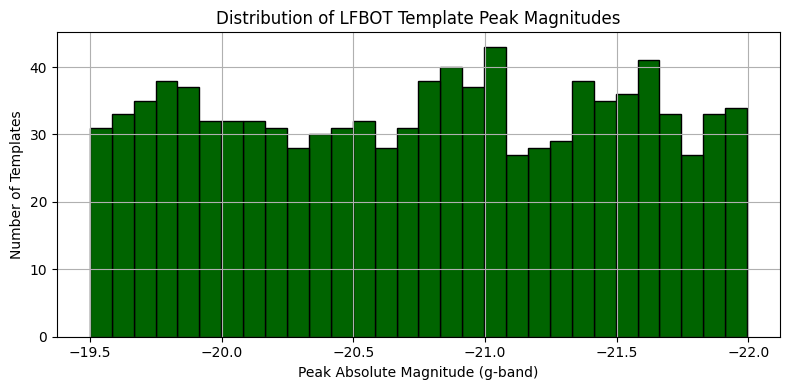

In [117]:
# Assume lc_model is your instance of LC or loaded via shared_utils
g_peak_mags = []

for lc in shared_lc_model.data:
    g_band_mag = lc['g']['mag']
    peak_mag = np.min(g_band_mag)
    g_peak_mags.append(peak_mag)

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(g_peak_mags, bins=30, edgecolor='black', color='darkgreen')
plt.xlabel("Peak Absolute Magnitude (g-band)")
plt.ylabel("Number of Templates")
plt.title("Distribution of LFBOT Template Peak Magnitudes")
plt.gca().invert_xaxis()  # brighter to the left
plt.grid(True)
plt.tight_layout()
plt.show()
